# **Exploratory Data Analysis**

## **Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## **Load Data**

### **Perkenalan Dataset**

**Sumber Dataset**:

- Dataset diperoleh dari data pengumpulan sensor IoT yang diunduh dari platform IoT Cloud Thingspeak

In [2]:
df = pd.read_csv(r'..\data\raw\ENV_data_2025-06-21_to_2025-06-24.csv')

df

,created_at,Temperature,Humidity,PM2.5,PM10,CO,CO2
0,2025-06-21 07:00:15+07:00,24.8,84.3,52.7,72.50000,0.59860,403.34171
1,2025-06-21 07:01:04+07:00,24.8,84.1,50.4,66.70000,0.56109,403.40472
2,2025-06-21 07:01:53+07:00,24.8,84.0,51.7,74.00000,0.54466,403.36261
3,2025-06-21 07:02:43+07:00,24.9,83.6,49.7,65.90000,0.55447,403.30020
4,2025-06-21 07:03:32+07:00,24.9,83.3,51.6,72.70000,0.57113,403.29333
...,...,...,...,...,...,...,...
5073,2025-06-24 06:56:08+07:00,24.4,83.9,113.6,167.50000,1.00010,406.77890
5074,2025-06-24 06:56:58+07:00,24.4,83.8,114.1,167.80000,1.00534,406.49930
5075,2025-06-24 06:57:47+07:00,24.5,83.7,107.8,162.00000,1.11194,406.55923
5076,2025-06-24 06:58:39+07:00,24.5,83.7,107.3,159.60001,1.01324,406.48737


In [3]:
df = df[(df['CO2'] >= 400) & (df['CO'] <= 100) & (df['CO'] > 0.1)]

In [4]:
df.isna().sum()

created_at     0
Temperature    0
Humidity       0
PM2.5          0
PM10           0
CO             0
CO2            0
dtype: int64

## **Exploratory Data Analysis**

In [5]:
df['created_at'] = pd.to_datetime(df['created_at'])

In [6]:
df = df.set_index('created_at')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5078 entries, 2025-06-21 07:00:15+07:00 to 2025-06-24 06:59:29+07:00
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  5078 non-null   float64
 1   Humidity     5078 non-null   float64
 2   PM2.5        5078 non-null   float64
 3   PM10         5078 non-null   float64
 4   CO           5078 non-null   float64
 5   CO2          5078 non-null   float64
dtypes: float64(6)
memory usage: 277.7 KB


In [8]:
df.describe()

,Temperature,Humidity,PM2.5,PM10,CO,CO2
count,5078.000000,5078.000000,5078.000000,5078.000000,5078.000000,5078.000000
mean,26.665065,79.720737,65.699508,88.851891,0.521105,403.800821
std,1.429881,7.733125,31.054185,45.502388,0.164874,0.859799
min,24.000000,53.800000,10.500000,12.100000,0.290700,402.755190
25%,25.500000,73.800000,40.800000,50.550000,0.418170,403.341710
50%,26.300000,82.500000,64.550000,86.000000,0.466560,403.562770
75%,27.900000,85.300000,83.500000,118.300000,0.556120,403.803160
max,29.600000,91.600000,155.899990,216.700000,1.134870,406.979250


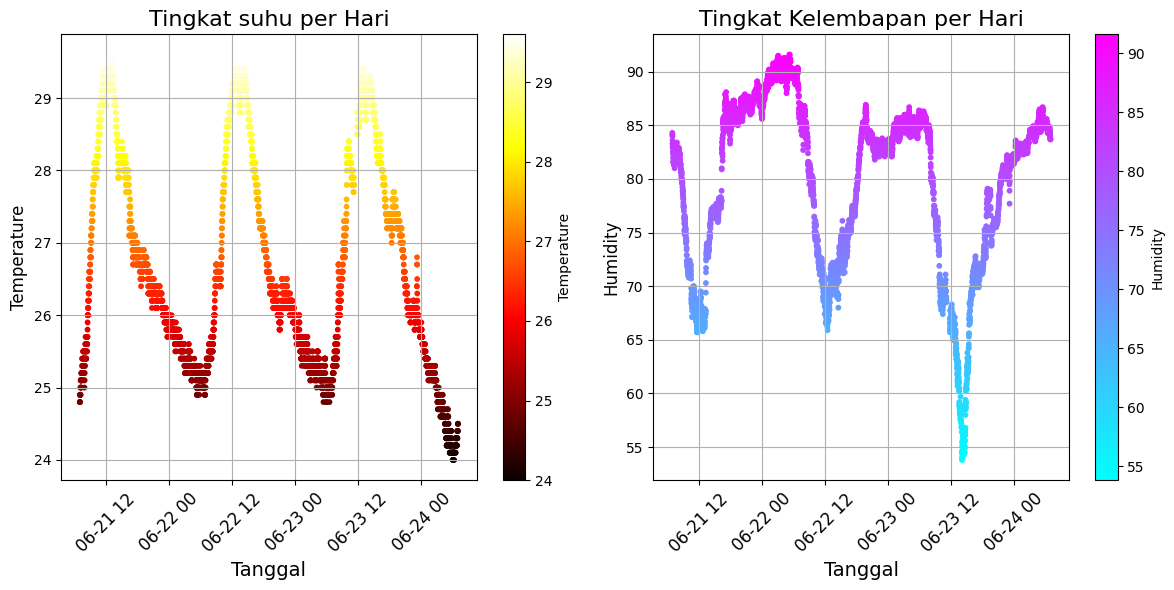

In [9]:
plt.figure(figsize=(12, 6))

plt.subplot(121)
plt.scatter(df.index, df['Temperature'], c=df['Temperature'], cmap='hot', s=10)
plt.title('Tingkat suhu per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('Temperature', fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.colorbar(label='Temperature')
plt.grid(True)

plt.subplot(122)
plt.scatter(df.index, df['Humidity'], c=df['Humidity'], cmap='cool', s=10)
plt.title('Tingkat Kelembapan per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('Humidity', fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.colorbar(label='Humidity')
plt.grid(True)

plt.tight_layout()
plt.show()

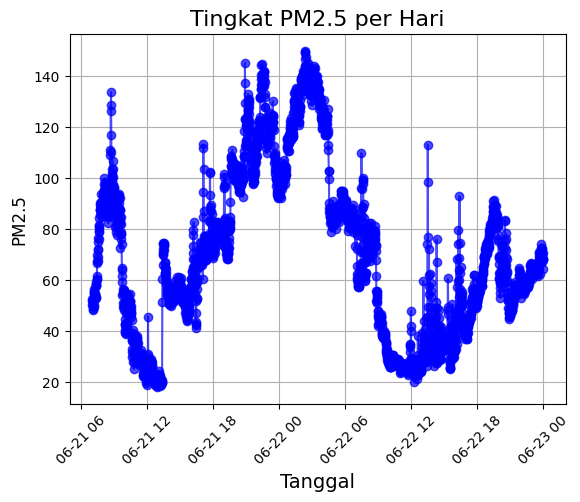

In [10]:
plt.plot(df['PM2.5']['2025-06-21':'2025-06-22'], marker='o', color='blue', alpha=0.7)
plt.title('Tingkat PM2.5 per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('PM2.5', fontsize=12)
plt.tick_params(axis='x', rotation=45)
plt.grid(True)

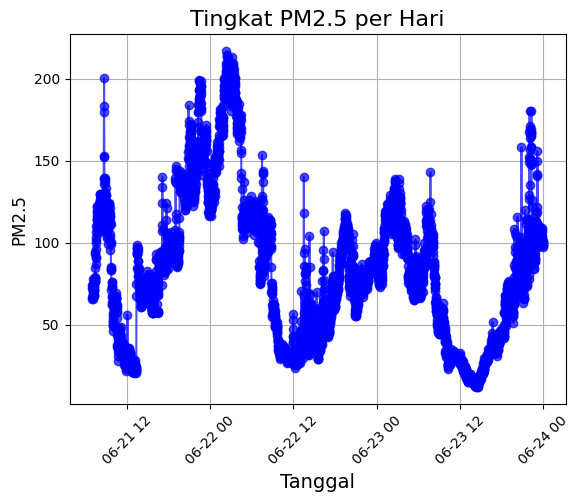

In [11]:
plt.plot(df['PM10']['2025-06-21':'2025-06-23'], marker='o', color='blue', alpha=0.7)
plt.title('Tingkat PM2.5 per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('PM2.5', fontsize=12)
plt.tick_params(axis='x', rotation=45)
plt.grid(True)

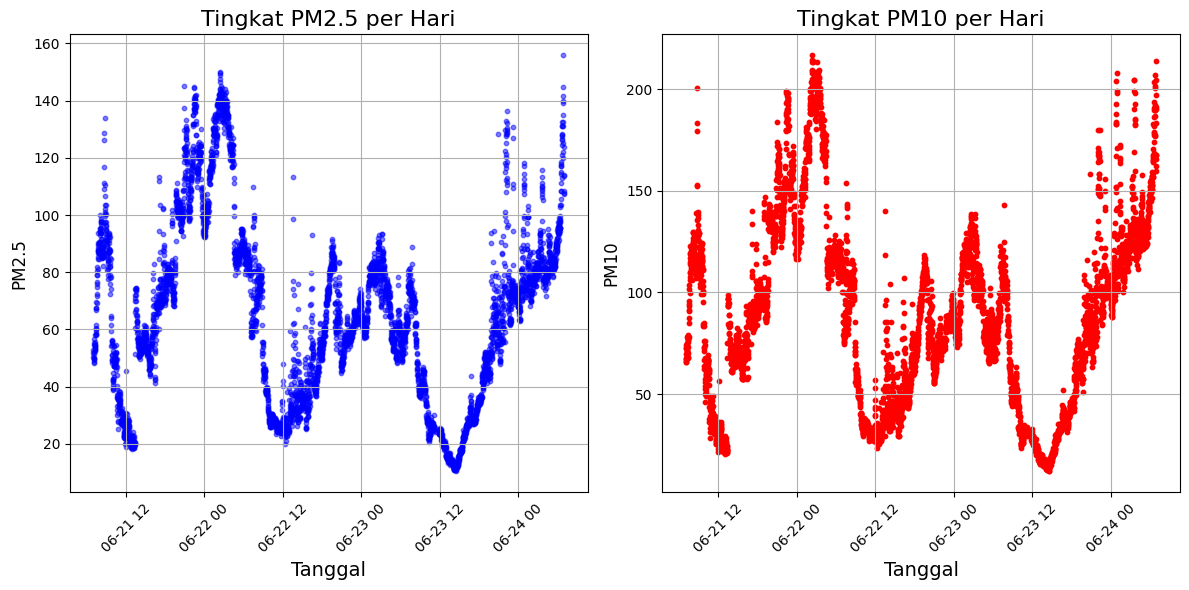

In [12]:
plt.figure(figsize=(12, 6))

ax1 = plt.subplot(121)
ax1.scatter(df.index, df['PM2.5'], s=10, c='blue', alpha=0.5)
ax1.set_title('Tingkat PM2.5 per Hari', fontsize=16)
ax1.set_xlabel('Tanggal', fontsize=14)
ax1.set_ylabel('PM2.5', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True)

ax2 = plt.subplot(122)
ax2.scatter(df.index, df['PM10'], s=10, c='red')
ax2.set_title('Tingkat PM10 per Hari', fontsize=16)
ax2.set_xlabel('Tanggal', fontsize=14)
ax2.set_ylabel('PM10', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True)


plt.tight_layout()
plt.show()

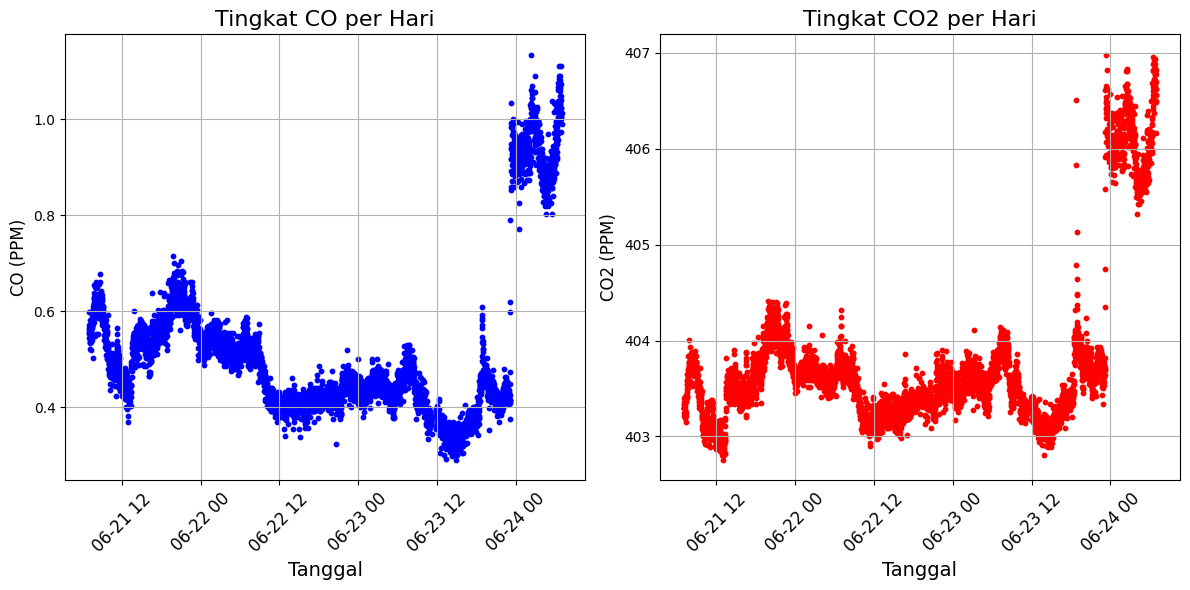

In [13]:
plt.figure(figsize=(12, 6))

plt.subplot(121)
plt.scatter(df.index, df['CO'], s=10, color='blue')
plt.title('Tingkat CO per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('CO (PPM)', fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.grid(True)

plt.subplot(122)
plt.scatter(df.index, df['CO2'], s=10, color='red')
plt.title('Tingkat CO2 per Hari', fontsize=16)
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('CO2 (PPM)', fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.grid(True)

plt.tight_layout()
plt.show()

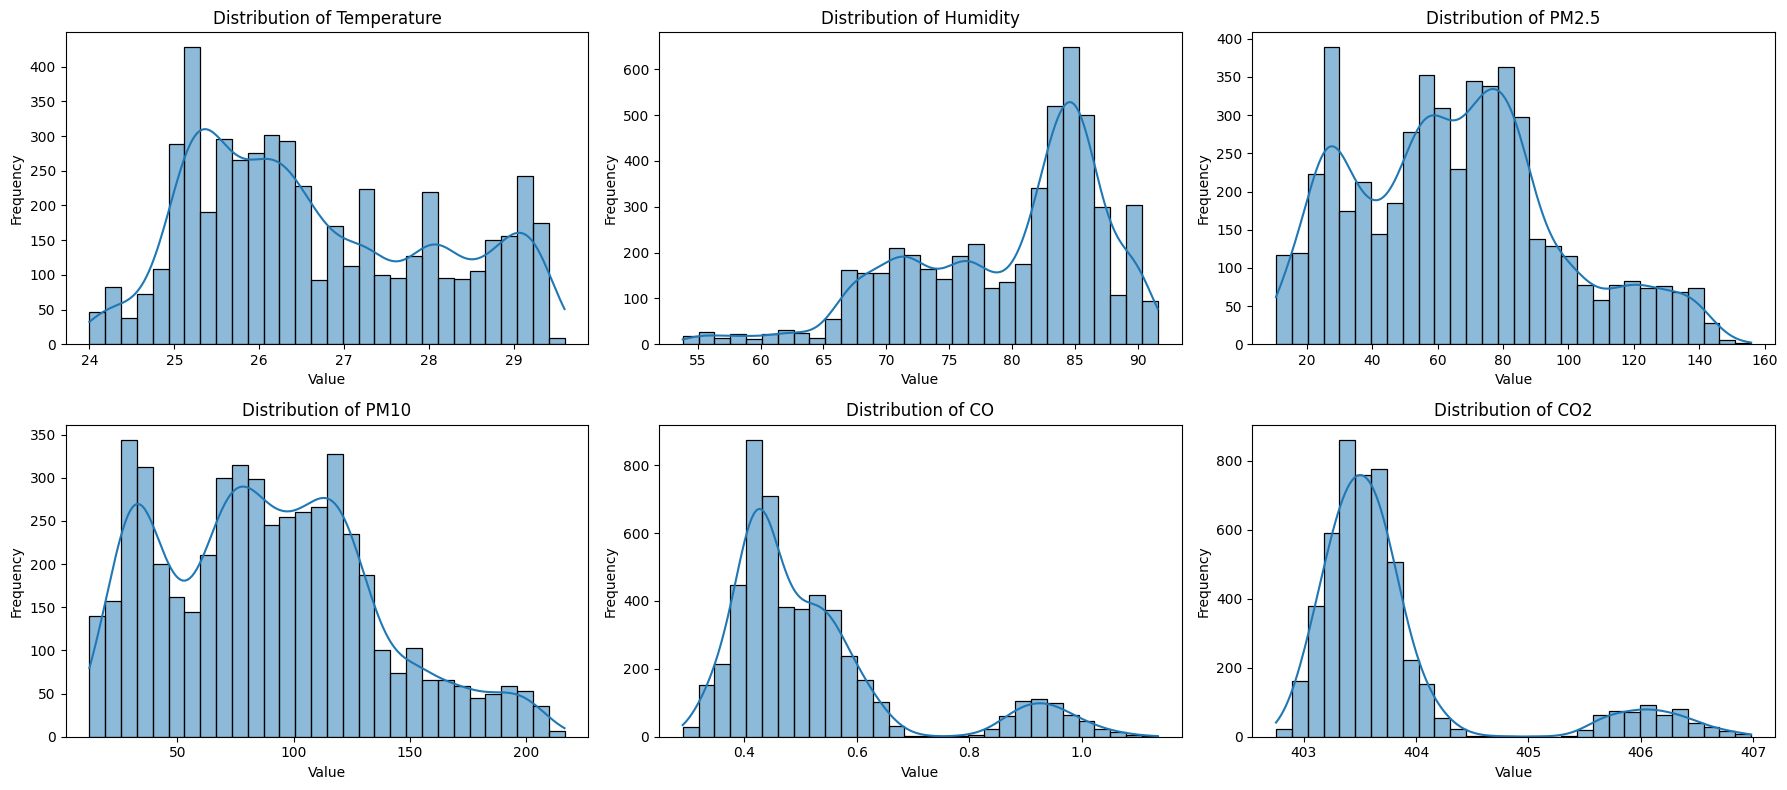

In [14]:
# Daftar nama kolom
columns_to_plot = df.columns.tolist()
 
# Menentukan jumlah baris dan kolom untuk subplot()
n_cols = 3  # Jumlah kolom pada grid subplot
n_rows = -(-len(columns_to_plot) // n_cols)  # Ceiling division untuk menentukan jumlah baris

# Membuat kanvas utama
plt.figure(figsize=(n_cols * 6, n_rows * 4))

# Membuat histogram untuk setiap kolom
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(n_rows, n_cols, i)  # Menentukan posisi subplot
    sns.histplot(df[column], kde=True, bins=30)
    plt.title(f'Distribution of {column}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

# Menyesuaikan tata letak dan menampilkan grafik
plt.tight_layout()
plt.show()

In [15]:
df.skew()

Temperature    0.389923
Humidity      -0.831361
PM2.5          0.403511
PM10           0.420899
CO             1.693172
CO2            2.101801
dtype: float64

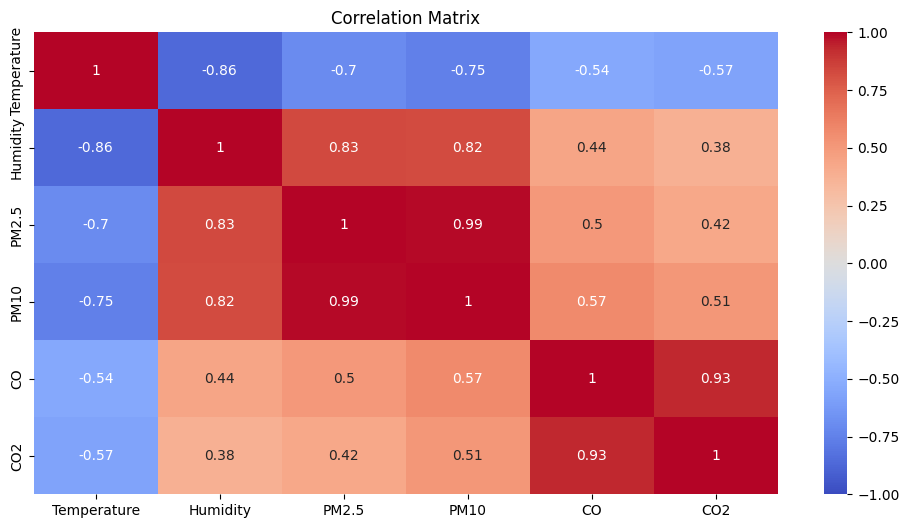

In [16]:
# Visualisasi korelasi antar variabel
plt.figure(figsize=(12, 6))

correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()

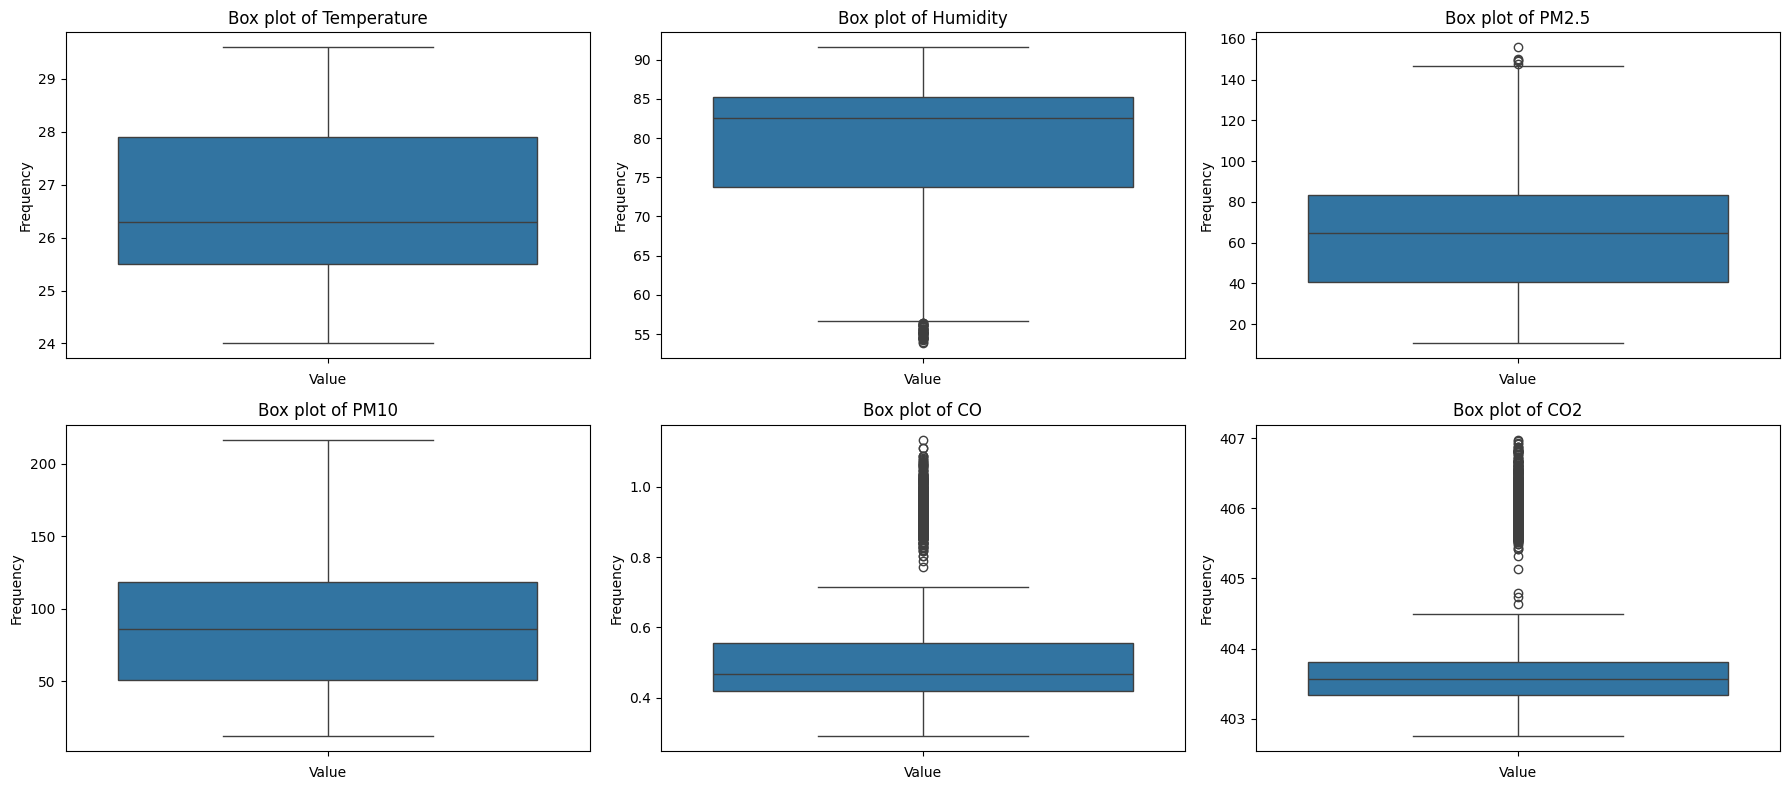

In [17]:
# Daftar nama kolom
columns_to_plot = df.columns.tolist()
 
# Menentukan jumlah baris dan kolom untuk subplot()
n_cols = 3  # Jumlah kolom pada grid subplot
n_rows = -(-len(columns_to_plot) // n_cols)  # Ceiling division untuk menentukan jumlah baris

# Membuat kanvas utama
plt.figure(figsize=(n_cols * 6, n_rows * 4))

# Membuat histogram untuk setiap kolom
for i, column in enumerate(columns_to_plot, 1):
    plt.subplot(n_rows, n_cols, i)  # Menentukan posisi subplot
    sns.boxplot(df[column])
    plt.title(f'Box plot of {column}')
    plt.xlabel('Value')
    plt.ylabel('Frequency')

# Menyesuaikan tata letak dan menampilkan grafik
plt.tight_layout()
plt.show()

## Hasil Exploratory Data Analysis

### Periode Data
Data yang digunakan berasal dari tanggal **21 Juni 2025** hingga **23 Juni 2025**, diambil dari sensor IoT berbasis SDS011, DHT22, MQ7, dan MQ135. 

Sensor telah ditempatkan di luar ruangan dengan ventilasi silang, arah gravitasi sesuai spesifikasi SDS011, serta tidak ada gangguan struktural terhadap inlet udara.

---

### Distribusi dan Skewness

#### Temperature
- **Skewness**: **0.39** → sedikit miring ke kanan
- **Distribusi**: Hampir normal dengan puncak di 26–27°C, variasi ringan
- **Insight**: Stabil, tanpa outlier. Menunjukkan suhu lingkungan luar yang normal

#### Humidity
- **Skewness**: **−0.83** → miring ke kiri (negatif)
- **Distribusi**: Tinggi di kisaran 80–90% RH
- **Insight**: Sangat umum untuk daerah tropis seperti Bandung, terutama malam hari

#### PM2.5
- **Skewness**: **0.40** → sedikit miring ke kanan
- **Distribusi**: Multimodal, dominan di kisaran 40–100 µg/m³
- **Insight**: Tidak sepenuhnya normal. Nilai tinggi bisa berasal dari aktivitas lokal (kendaraan, asap)

#### PM10
- **Skewness**: **0.42** → miring ke kanan ringan
- **Distribusi**: Mirip PM2.5 dengan nilai lebih tinggi
- **Insight**: Sangat berkorelasi dengan PM2.5, menunjukkan sumber partikulat yang sama

#### CO
- **Skewness**: **1.69** → miring kanan signifikan
- **Distribusi**: Sebagian besar rendah, dengan lonjakan ekstrem
- **Insight**: Indikasi paparan CO lokal seperti kendaraan, asap pembakaran

#### CO₂
- **Skewness**: **2.10** → sangat miring ke kanan
- **Distribusi**: Dominan di 403–404 ppm, naik hingga 406–407 ppm
- **Insight**: CO₂ stabil namun menunjukkan peningkatan akibat aktivitas manusia

---

### Korelasi Antar Variabel (Heatmap)

| Variabel 1   | Variabel 2   | Koefisien | Interpretasi                                               |
|--------------|---------------|-----------|-------------------------------------------------------------|
| PM2.5        | PM10          | **0.99**  | Hampir identik, polusi partikulat terjadi bersamaan        |
| CO           | CO₂           | **0.93**  | Polutan gas berkorelasi tinggi, bisa berasal dari pembakaran |
| Humidity     | PM2.5         | **0.83**  | Kelembapan tinggi mempengaruhi partikel terdeteksi         |
| Humidity     | PM10          | **0.82**  | Sama seperti PM2.5, karena sifat fisik partikel serupa      |
| Temperature  | Humidity      | **−0.86** | Semakin panas, kelembapan cenderung turun                  |
| Temperature  | PM2.5         | **−0.70** | Korelasi negatif – distribusi partikel lebih tinggi saat suhu rendah |

---

### Kesimpulan EDA
- Data setelah tanggal **21 Juni** bersifat stabil dan representatif.
- **Distribusi variabel** cenderung miring ke kanan pada variabel polusi udara, sesuai dengan karakteristik alami partikel dan gas di udara bebas.
- **Korelasi antar variabel** memberikan insight penting bahwa PM2.5 & PM10 bisa dianalisis bersama, dan bahwa CO & CO₂ saling memperkuat indikasi sumber polusi gas.
- **Humidity dan temperature** memiliki peran penting sebagai **faktor lingkungan**, yang memengaruhi konsentrasi partikel dan gas.

